# **"Hybrid Movie Recommendation System"**




# **Section 1: Install Required Libraries**

In [2]:
# Install required libraries
!pip install scikit-surprise

# **Section 2: Import Libraries**

In [3]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Recommendation system library
from surprise import Dataset, Reader, SVD, KNNBasic
from surprise.model_selection import cross_validate, train_test_split as surprise_train_test_split
from surprise import accuracy as surprise_accuracy

print("All libraries imported successfully!")

All libraries imported successfully!


# **Section 3: Load Data**



In [4]:
def load_movielens_data():
    """Load MovieLens 100K dataset"""

    print("Loading MovieLens 100K data...")

    # Load ratings data
    ratings = pd.read_csv(
        '/content/ml-100k/ml-100k/u.data',
        sep='\t',
        names=['user_id', 'movie_id', 'rating', 'timestamp']
    )

    # Load movies data
    movies = pd.read_csv(
        '/content/ml-100k/ml-100k/u.item',
        sep='|',
        encoding='latin-1',
        header=None,
        names=[
            'movie_id', 'title', 'release_date', 'video_release', 'imdb_url',
            'unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy',
            'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
            'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
        ]
    )

    # Load users data
    users = pd.read_csv(
        '/content/ml-100k/ml-100k/u.user',
        sep='|',
        names=['user_id', 'age', 'gender', 'occupation', 'zip_code']
    )

    return ratings, movies, users

# Load the data
ratings, movies, users = load_movielens_data()

print("Data Summary:")
print(f"Total Ratings: {len(ratings):,}")
print(f"Total Movies: {len(movies):,}")
print(f"Total Users: {len(users):,}")
print("\n First 5 rows of each dataset:")

print("\nRatings DataFrame:")
print(ratings.head())

print("\nMovies DataFrame:")
print(movies[['movie_id', 'title', 'release_date']].head())

print("\nUsers DataFrame:")
print(users.head())

Loading MovieLens 100K data...
Data Summary:
Total Ratings: 100,000
Total Movies: 1,682
Total Users: 943

 First 5 rows of each dataset:

Ratings DataFrame:
   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596

Movies DataFrame:
   movie_id              title release_date
0         1   Toy Story (1995)  01-Jan-1995
1         2   GoldenEye (1995)  01-Jan-1995
2         3  Four Rooms (1995)  01-Jan-1995
3         4  Get Shorty (1995)  01-Jan-1995
4         5     Copycat (1995)  01-Jan-1995

Users DataFrame:
   user_id  age gender  occupation zip_code
0        1   24      M  technician    85711
1        2   53      F       other    94043
2        3   23      M      writer    32067
3        4   24      M  technician    43537
4        5   33      F       other    15213


# **Section 4: Exploratory Data Analysis**

Exploratory Data Analysis

1. Basic Statistics:
Ratings Statistics:
count    100000.000000
mean          3.529860
std           1.125674
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

Users Age Statistics:
count    943.000000
mean      34.051962
std       12.192740
min        7.000000
25%       25.000000
50%       31.000000
75%       43.000000
max       73.000000
Name: age, dtype: float64

Gender Distribution:
gender
M    670
F    273
Name: count, dtype: int64


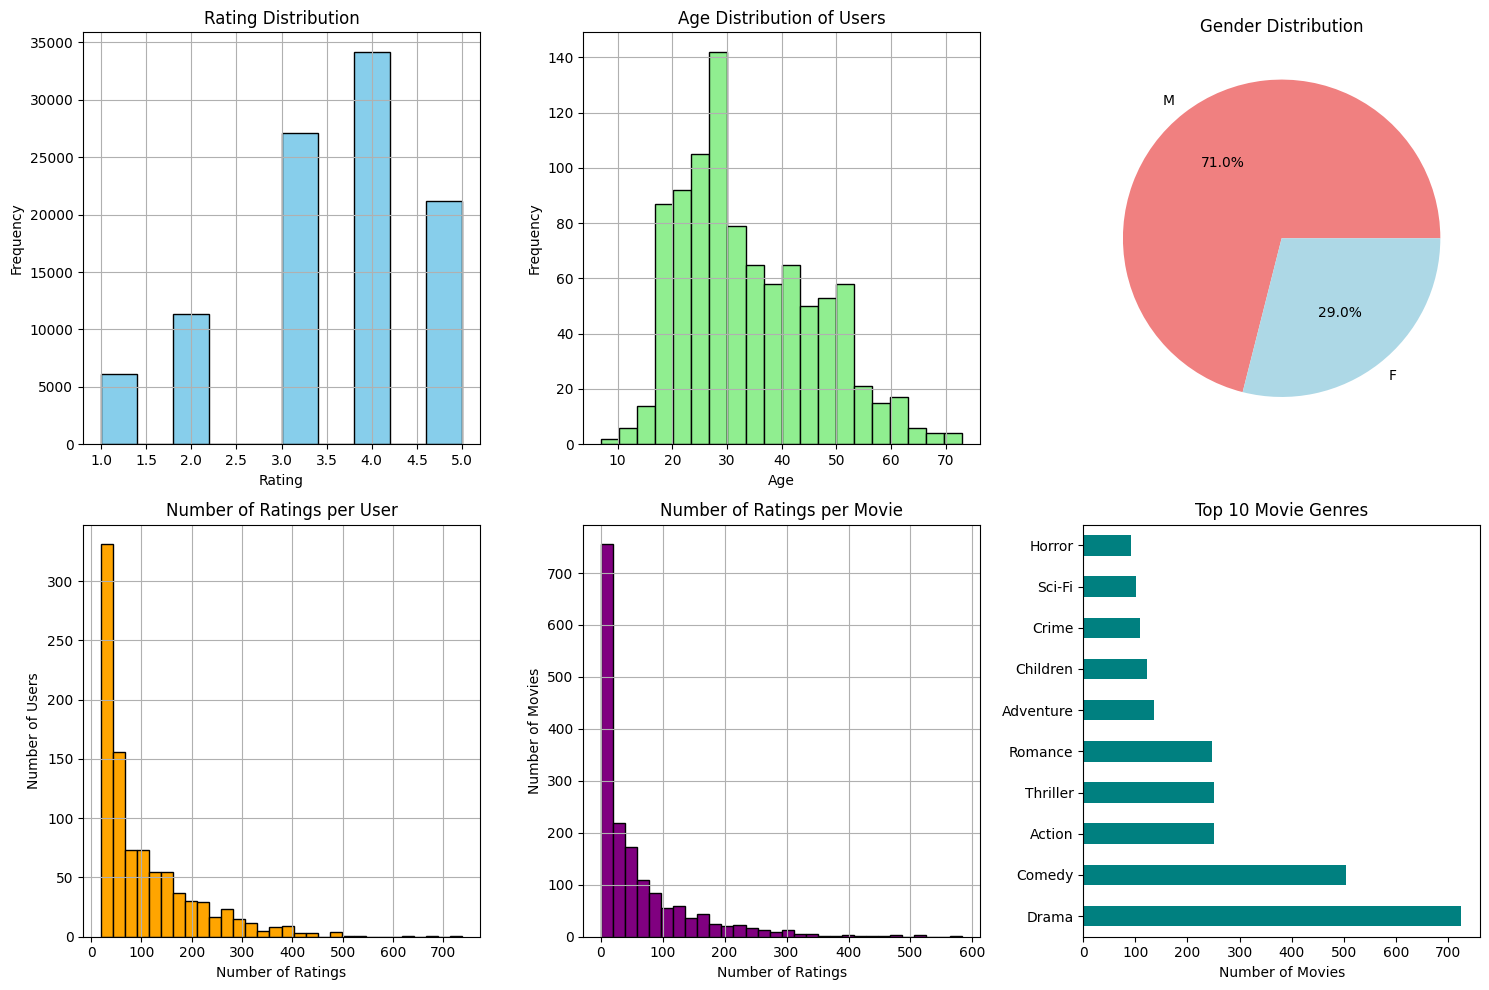


2. Top 10 Most Rated Movies:
                        title  rating_count  rating_mean
             Star Wars (1977)           583         4.36
               Contact (1997)           509         3.80
                 Fargo (1996)           508         4.16
    Return of the Jedi (1983)           507         4.01
             Liar Liar (1997)           485         3.16
  English Patient, The (1996)           481         3.66
                Scream (1996)           478         3.44
             Toy Story (1995)           452         3.88
         Air Force One (1997)           431         3.63
Independence Day (ID4) (1996)           429         3.44


In [5]:
def perform_eda(ratings, movies, users):
    """Perform Exploratory Data Analysis"""

    print("Exploratory Data Analysis")
    print("="*50)

    # 1. Basic statistics
    print("\n1. Basic Statistics:")
    print("Ratings Statistics:")
    print(ratings['rating'].describe())

    print("\nUsers Age Statistics:")
    print(users['age'].describe())

    print("\nGender Distribution:")
    print(users['gender'].value_counts())

    # 2. Visualizations
    plt.figure(figsize=(15, 10))

    # Rating distribution
    plt.subplot(2, 3, 1)
    ratings['rating'].hist(bins=10, edgecolor='black', color='skyblue')
    plt.title('Rating Distribution')
    plt.xlabel('Rating')
    plt.ylabel('Frequency')

    # Age distribution
    plt.subplot(2, 3, 2)
    users['age'].hist(bins=20, edgecolor='black', color='lightgreen')
    plt.title('Age Distribution of Users')
    plt.xlabel('Age')
    plt.ylabel('Frequency')

    # Gender distribution
    plt.subplot(2, 3, 3)
    gender_counts = users['gender'].value_counts()
    plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['lightcoral', 'lightblue'])
    plt.title('Gender Distribution')

    # Ratings per user
    plt.subplot(2, 3, 4)
    user_rating_counts = ratings['user_id'].value_counts()
    user_rating_counts.hist(bins=30, edgecolor='black', color='orange')
    plt.title('Number of Ratings per User')
    plt.xlabel('Number of Ratings')
    plt.ylabel('Number of Users')

    # Ratings per movie
    plt.subplot(2, 3, 5)
    movie_rating_counts = ratings['movie_id'].value_counts()
    movie_rating_counts.hist(bins=30, edgecolor='black', color='purple')
    plt.title('Number of Ratings per Movie')
    plt.xlabel('Number of Ratings')
    plt.ylabel('Number of Movies')

    # Top movie genres
    plt.subplot(2, 3, 6)
    genre_cols = [col for col in movies.columns if col not in
                  ['movie_id', 'title', 'release_date', 'video_release', 'imdb_url', 'unknown']]
    genre_counts = movies[genre_cols].sum().sort_values(ascending=False).head(10)
    genre_counts.plot(kind='barh', color='teal')
    plt.title('Top 10 Movie Genres')
    plt.xlabel('Number of Movies')

    plt.tight_layout()
    plt.show()

    # 3. Top rated movies
    print("\n2. Top 10 Most Rated Movies:")
    movie_stats = ratings.groupby('movie_id').agg({
        'rating': ['count', 'mean']
    }).round(2)
    movie_stats.columns = ['rating_count', 'rating_mean']
    top_movies = movie_stats.sort_values('rating_count', ascending=False).head(10)
    top_movies_with_titles = top_movies.merge(movies[['movie_id', 'title']], on='movie_id')
    print(top_movies_with_titles[['title', 'rating_count', 'rating_mean']].to_string(index=False))

# Run EDA
perform_eda(ratings, movies, users)

# **Section 5: Data Preprocessing**

In [8]:
def preprocess_data(ratings, movies, users):
    """Preprocess and clean the data"""

    print("Data Preprocessing")
    print("="*50)

    # Merge datasets
    print("1. Merging datasets...")
    ratings_with_movies = pd.merge(ratings, movies[['movie_id', 'title']], on='movie_id')
    full_data = pd.merge(ratings_with_movies, users, on='user_id')

    # Handle missing values
    print("2. Checking for missing values...")
    print(f"Missing values in ratings: {ratings.isnull().sum().sum()}")
    print(f"Missing values in movies: {movies.isnull().sum().sum()}")
    print(f"Missing values in users: {users.isnull().sum().sum()}")

    # Add date features
    print("3. Creating date features...")
    full_data['date'] = pd.to_datetime(full_data['timestamp'], unit='s')
    full_data['year'] = full_data['date'].dt.year
    full_data['month'] = full_data['date'].dt.month

    # Create user features
    print("4. Creating user features...")
    user_rating_counts = ratings['user_id'].value_counts().reset_index()
    user_rating_counts.columns = ['user_id', 'user_rating_count']

    # Create movie features
    print("5. Creating movie features...")
    movie_rating_counts = ratings['movie_id'].value_counts().reset_index()
    movie_rating_counts.columns = ['movie_id', 'movie_rating_count']

    movie_avg_ratings = ratings.groupby('movie_id')['rating'].mean().reset_index()
    movie_avg_ratings.columns = ['movie_id', 'movie_avg_rating']

    # Merge features
    full_data = full_data.merge(user_rating_counts, on='user_id')
    full_data = full_data.merge(movie_rating_counts, on='movie_id')
    full_data = full_data.merge(movie_avg_ratings, on='movie_id')

    # Encode categorical variables
    print("6. Encoding categorical variables...")
    full_data['gender_encoded'] = full_data['gender'].map({'M': 0, 'F': 1})

    # Get top occupations for one-hot encoding
    top_occupations = full_data['occupation'].value_counts().head(10).index.tolist()
    for occupation in top_occupations:
        full_data[f'occupation_{occupation}'] = (full_data['occupation'] == occupation).astype(int)

    print(f"\nPreprocessing complete!")
    print(f"Final dataset shape: {full_data.shape}")
    print(f"Number of features: {len(full_data.columns)}")

    return full_data

# Preprocess data
full_data = preprocess_data(ratings, movies, users)
print("\nSample of processed data:")
print(full_data[['user_id', 'movie_id', 'title', 'rating', 'age', 'gender', 'user_rating_count']].head())

Data Preprocessing
1. Merging datasets...
2. Checking for missing values...
Missing values in ratings: 0
Missing values in movies: 1686
Missing values in users: 0
3. Creating date features...
4. Creating user features...
5. Creating movie features...
6. Encoding categorical variables...

Preprocessing complete!
Final dataset shape: (100000, 26)
Number of features: 26

Sample of processed data:
   user_id  movie_id                       title  rating  age gender  \
0      196       242                Kolya (1996)       3   49      M   
1      186       302    L.A. Confidential (1997)       3   39      F   
2       22       377         Heavyweights (1994)       1   25      M   
3      244        51  Legends of the Fall (1994)       2   28      M   
4      166       346         Jackie Brown (1997)       1   47      M   

   user_rating_count  
0                 39  
1                 92  
2                128  
3                238  
4                 20  


# **Section 6: Clustering Analysis with K-Means**

Clustering Analysis with K-Means
1. Preparing genre data...
2. Scaling the data...
3. Finding optimal number of clusters (Elbow Method)...


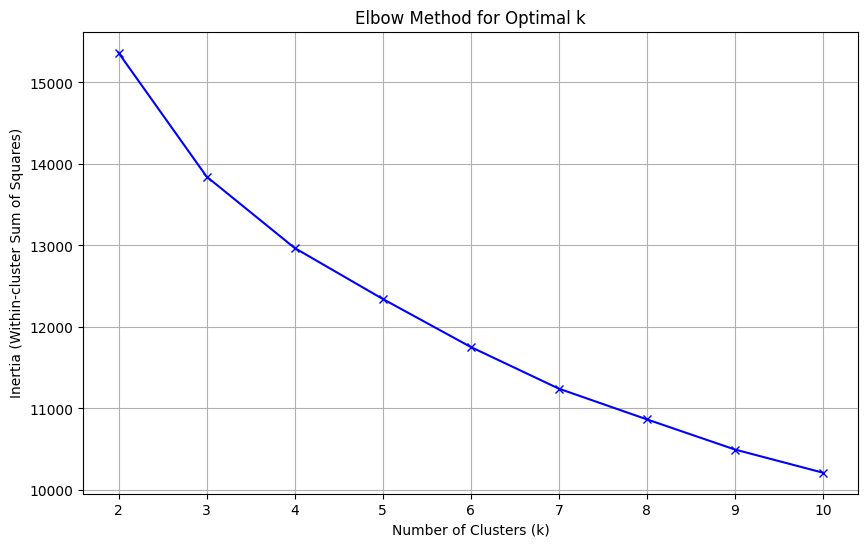

Selected optimal k: 5
4. Applying K-Means clustering...

5. Cluster Analysis:
------------------------------
Cluster 0: 216 users (22.9%)
Cluster 1: 257 users (27.3%)
Cluster 2: 106 users (11.2%)
Cluster 3: 286 users (30.3%)
Cluster 4: 78 users (8.3%)

Average Age per Cluster:
Cluster 0: 33.8 years
Cluster 1: 42.5 years
Cluster 2: 29.9 years
Cluster 3: 29.4 years
Cluster 4: 29.7 years

Top 3 Genres per Cluster:
Cluster 0: Drama, Thriller, Action
Cluster 1: Drama, Comedy, Romance
Cluster 2: Action, Drama, Thriller
Cluster 3: Drama, Comedy, Action
Cluster 4: Comedy, Action, Drama

6. Visualizing clusters with PCA...


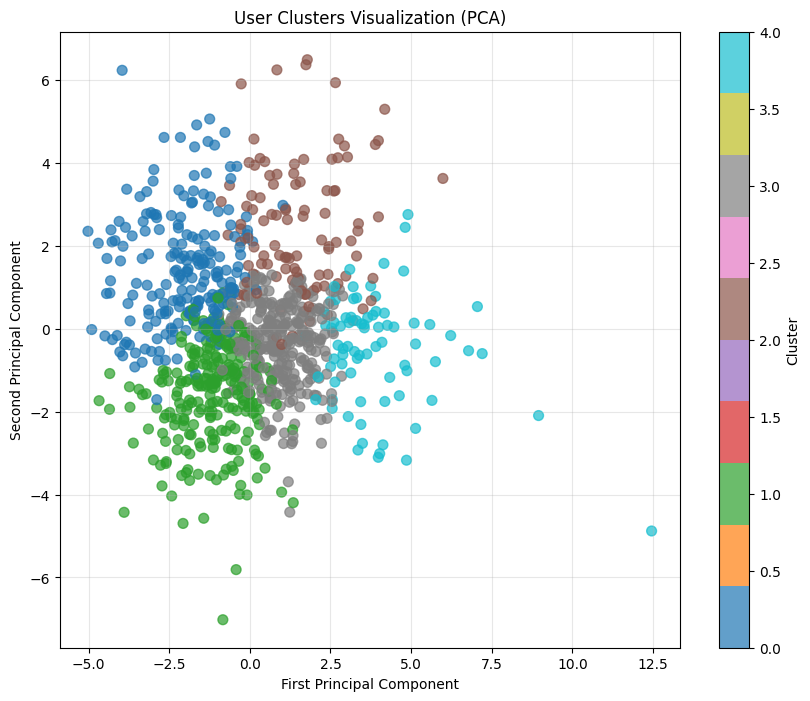

In [9]:
def perform_clustering_analysis(full_data, movies):
    """Perform clustering analysis on users"""

    print("Clustering Analysis with K-Means")
    print("="*50)

    # Prepare genre data for clustering
    print("1. Preparing genre data...")
    genre_cols = [col for col in movies.columns if col not in
                  ['movie_id', 'title', 'release_date', 'video_release', 'imdb_url', 'unknown']]

    # Calculate user genre preferences
    user_genre_prefs = pd.merge(ratings[['user_id', 'movie_id']],
                                movies[['movie_id'] + genre_cols],
                                on='movie_id')
    user_genre_means = user_genre_prefs.groupby('user_id')[genre_cols].mean().reset_index()

    # Merge with user data
    users_with_genres = pd.merge(users, user_genre_means, on='user_id', how='left')
    users_with_genres[genre_cols] = users_with_genres[genre_cols].fillna(0)

    # Scale the data
    print("2. Scaling the data...")
    scaler = StandardScaler()
    clustering_data = users_with_genres[['age'] + genre_cols]
    scaled_data = scaler.fit_transform(clustering_data)

    # Find optimal K using Elbow Method
    print("3. Finding optimal number of clusters (Elbow Method)...")
    inertias = []
    k_range = range(2, 11)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(scaled_data)
        inertias.append(kmeans.inertia_)

    # Plot Elbow Method
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, inertias, 'bx-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia (Within-cluster Sum of Squares)')
    plt.title('Elbow Method for Optimal k')
    plt.grid(True)
    plt.show()

    # Choose optimal k (from elbow point)
    optimal_k = 5
    print(f"Selected optimal k: {optimal_k}")

    # Apply K-Means with optimal k
    print("4. Applying K-Means clustering...")
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    users_with_genres['kmeans_cluster'] = kmeans.fit_predict(scaled_data)

    # Analyze clusters
    print("\n5. Cluster Analysis:")
    print("-"*30)

    # Cluster sizes
    cluster_sizes = users_with_genres['kmeans_cluster'].value_counts().sort_index()
    for cluster, size in cluster_sizes.items():
        percentage = size/len(users_with_genres)*100
        print(f"Cluster {cluster}: {size} users ({percentage:.1f}%)")

    # Average age per cluster
    print("\nAverage Age per Cluster:")
    age_by_cluster = users_with_genres.groupby('kmeans_cluster')['age'].mean()
    for cluster, avg_age in age_by_cluster.items():
        print(f"Cluster {cluster}: {avg_age:.1f} years")

    # Top genres per cluster
    print("\nTop 3 Genres per Cluster:")
    for cluster in range(optimal_k):
        cluster_data = users_with_genres[users_with_genres['kmeans_cluster'] == cluster]
        avg_genres = cluster_data[genre_cols].mean().sort_values(ascending=False).head(3)
        genres_str = ', '.join(avg_genres.index.tolist())
        print(f"Cluster {cluster}: {genres_str}")

    # Visualize clusters with PCA
    print("\n6. Visualizing clusters with PCA...")
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(scaled_data)

    users_with_genres['pca1'] = pca_result[:, 0]
    users_with_genres['pca2'] = pca_result[:, 1]

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(users_with_genres['pca1'],
                         users_with_genres['pca2'],
                         c=users_with_genres['kmeans_cluster'],
                         cmap='tab10', alpha=0.7, s=50)
    plt.colorbar(scatter, label='Cluster')
    plt.xlabel('First Principal Component')
    plt.ylabel('Second Principal Component')
    plt.title('User Clusters Visualization (PCA)')
    plt.grid(True, alpha=0.3)
    plt.show()

    return users_with_genres

# Perform clustering
users_with_clusters = perform_clustering_analysis(full_data, movies)

# **Section 7: Dimensionality Reduction with PCA**

Dimensionality Reduction with PCA
1. Original number of genre features: 18
2. Applying PCA...


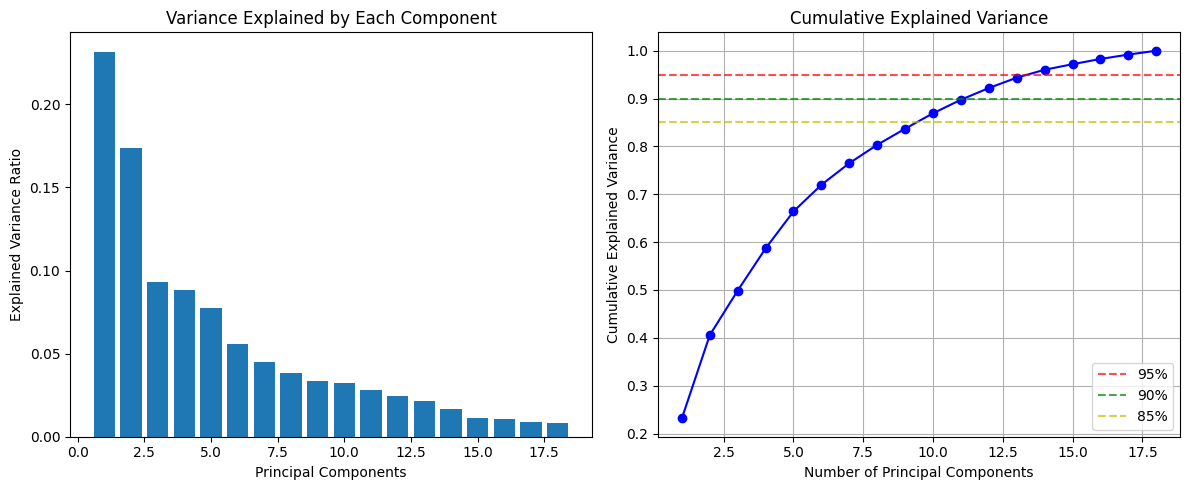

3. Finding optimal number of components...
Components needed for 95% variance: 14
Components needed for 90% variance: 12
Components needed for 85% variance: 10

4. Selected 6 principal components
Original shape: (1682, 18)
Reduced shape: (1682, 6)
Variance retained: 71.98%

5. Top features in each principal component:
  PC1: Drama, Comedy, Action
  PC2: Comedy, Action, Thriller
  PC3: Romance, Children, Thriller
  PC4: Thriller, Adventure, Action
  PC5: Action, Comedy, Children
  PC6: Children, Thriller, Horror


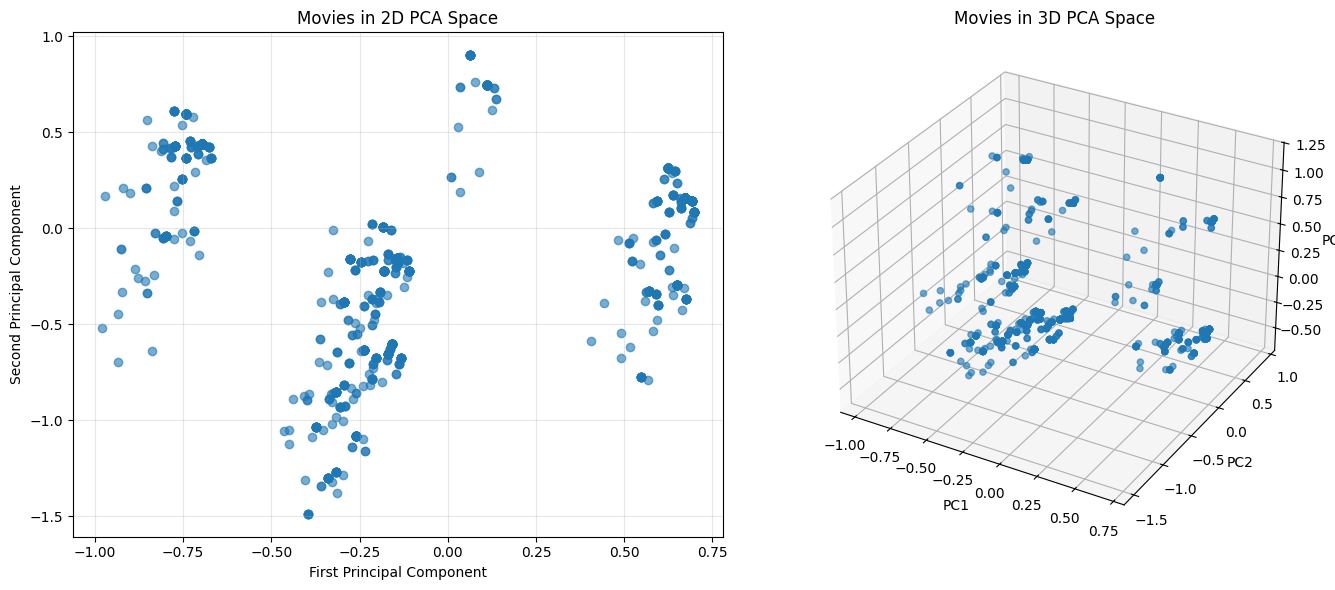

In [10]:
def perform_pca_analysis(movies):
    """Perform PCA for dimensionality reduction"""

    print("Dimensionality Reduction with PCA")
    print("="*50)

    # Extract genre features
    genre_cols = [col for col in movies.columns if col not in
                  ['movie_id', 'title', 'release_date', 'video_release', 'imdb_url', 'unknown']]

    print(f"1. Original number of genre features: {len(genre_cols)}")

    # Prepare data for PCA
    genre_data = movies[genre_cols].values

    # Apply PCA
    print("2. Applying PCA...")
    pca_full = PCA()
    pca_full.fit(genre_data)

    # Calculate cumulative variance
    cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

    # Plot explained variance
    plt.figure(figsize=(12, 5))

    # Individual variance
    plt.subplot(1, 2, 1)
    plt.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_)
    plt.xlabel('Principal Components')
    plt.ylabel('Explained Variance Ratio')
    plt.title('Variance Explained by Each Component')

    # Cumulative variance
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('Cumulative Explained Variance')
    plt.grid(True)
    plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='95%')
    plt.axhline(y=0.90, color='g', linestyle='--', alpha=0.7, label='90%')
    plt.axhline(y=0.85, color='y', linestyle='--', alpha=0.7, label='85%')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Find optimal number of components
    print("3. Finding optimal number of components...")
    n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
    n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
    n_components_85 = np.argmax(cumulative_variance >= 0.85) + 1

    print(f"Components needed for 95% variance: {n_components_95}")
    print(f"Components needed for 90% variance: {n_components_90}")
    print(f"Components needed for 85% variance: {n_components_85}")

    # Choose number of components
    chosen_n_components = 6
    print(f"\n4. Selected {chosen_n_components} principal components")

    # Apply PCA with selected components
    pca = PCA(n_components=chosen_n_components)
    genre_data_reduced = pca.fit_transform(genre_data)

    print(f"Original shape: {genre_data.shape}")
    print(f"Reduced shape: {genre_data_reduced.shape}")
    print(f"Variance retained: {pca.explained_variance_ratio_.sum():.2%}")

    # Analyze principal components
    print("\n5. Top features in each principal component:")
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=[f'PC{i+1}' for i in range(chosen_n_components)],
        index=genre_cols
    )

    for i in range(chosen_n_components):
        pc_name = f'PC{i+1}'
        top_features = loadings[pc_name].abs().sort_values(ascending=False).head(3)
        features_str = ', '.join(top_features.index.tolist())
        print(f"  {pc_name}: {features_str}")

    # Visualize reduced data
    plt.figure(figsize=(14, 6))

    # 2D visualization
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(genre_data_reduced[:, 0], genre_data_reduced[:, 1], alpha=0.6)
    plt.xlabel('First Principal Component')
    plt.ylabel('Second Principal Component')
    plt.title('Movies in 2D PCA Space')
    plt.grid(True, alpha=0.3)

    # 3D visualization
    from mpl_toolkits.mplot3d import Axes3D
    ax = plt.subplot(1, 2, 2, projection='3d')
    scatter = ax.scatter(genre_data_reduced[:, 0],
                        genre_data_reduced[:, 1],
                        genre_data_reduced[:, 2],
                        alpha=0.6)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.set_title('Movies in 3D PCA Space')

    plt.tight_layout()
    plt.show()

    return genre_data_reduced, pca

# Perform PCA analysis
genre_data_reduced, pca_model = perform_pca_analysis(movies)

# **Section 8: Build Recommendation System**

In [11]:
def build_recommendation_system(ratings):
    """Build collaborative filtering recommendation system"""

    print("Building Recommendation System")
    print("="*50)

    # Prepare data for Surprise library
    print("1. Preparing data for recommendation models...")
    reader = Reader(rating_scale=(1, 5))
    data = Dataset.load_from_df(ratings[['user_id', 'movie_id', 'rating']], reader)

    # Split data
    print("2. Splitting data (75% train, 25% test)...")
    trainset, testset = surprise_train_test_split(data, test_size=0.25, random_state=42)

    # Try different algorithms
    print("3. Training and comparing different algorithms...")

    algorithms = {
        'SVD': SVD(),
        'KNN (User-based)': KNNBasic(sim_options={'user_based': True}),
        'KNN (Item-based)': KNNBasic(sim_options={'user_based': False})
    }

    results = {}

    for name, algorithm in algorithms.items():
        print(f"\nTraining {name}...")

        # Train model
        algorithm.fit(trainset)

        # Make predictions
        predictions = algorithm.test(testset)

        # Calculate metrics
        rmse = surprise_accuracy.rmse(predictions, verbose=False)
        mae = surprise_accuracy.mae(predictions, verbose=False)

        results[name] = {
            'RMSE': rmse,
            'MAE': mae,
            'predictions': predictions
        }

        print(f"  RMSE: {rmse:.4f}")
        print(f"  MAE: {mae:.4f}")

    # Find best model
    print("\n4. Selecting best model...")
    best_model_name = min(results, key=lambda x: results[x]['RMSE'])
    best_model_metrics = results[best_model_name]

    print(f"Best model: {best_model_name}")
    print(f"Best RMSE: {best_model_metrics['RMSE']:.4f}")
    print(f"Best MAE: {best_model_metrics['MAE']:.4f}")

    # Train final model on full data
    print("\n5. Training final model on full dataset...")
    trainset_full = data.build_full_trainset()

    if best_model_name == 'SVD':
        final_model = SVD()
    else:
        final_model = KNNBasic(sim_options={'user_based': best_model_name == 'KNN (User-based)'})

    final_model.fit(trainset_full)

    # Compare models in a table
    print("\n6. Model Comparison Table:")
    print("-"*40)
    print(f"{'Model':<20} {'RMSE':<10} {'MAE':<10}")
    print("-"*40)
    for name, metrics in results.items():
        print(f"{name:<20} {metrics['RMSE']:<10.4f} {metrics['MAE']:<10.4f}")

    return final_model, results, best_model_name

# Build recommendation system
recommendation_model, model_results, best_model_name = build_recommendation_system(ratings)

Building Recommendation System
1. Preparing data for recommendation models...
2. Splitting data (75% train, 25% test)...
3. Training and comparing different algorithms...

Training SVD...
  RMSE: 0.9427
  MAE: 0.7441

Training KNN (User-based)...
Computing the msd similarity matrix...
Done computing similarity matrix.
  RMSE: 0.9854
  MAE: 0.7775

Training KNN (Item-based)...
Computing the msd similarity matrix...
Done computing similarity matrix.
  RMSE: 0.9786
  MAE: 0.7726

4. Selecting best model...
Best model: SVD
Best RMSE: 0.9427
Best MAE: 0.7441

5. Training final model on full dataset...

6. Model Comparison Table:
----------------------------------------
Model                RMSE       MAE       
----------------------------------------
SVD                  0.9427     0.7441    
KNN (User-based)     0.9854     0.7775    
KNN (Item-based)     0.9786     0.7726    


# **Section 9: Generate Recommendations**

In [12]:
def generate_movie_recommendations(model, user_id, movies_df, ratings_df, n_recommendations=10):
    """Generate movie recommendations for a specific user"""

    print(f"Generating Recommendations for User {user_id}")
    print("="*50)

    # Get movies the user has already watched
    watched_movies = ratings_df[ratings_df['user_id'] == user_id]['movie_id'].tolist()

    # Get all movies
    all_movies = movies_df['movie_id'].unique().tolist()

    # Find unwatched movies
    unwatched_movies = [movie for movie in all_movies if movie not in watched_movies]

    print(f"User {user_id} has watched {len(watched_movies)} movies")
    print(f"Number of unwatched movies: {len(unwatched_movies)}")

    # Predict ratings for unwatched movies
    print(f"\nPredicting ratings for unwatched movies...")
    predictions = []

    # Limit to first 500 for speed
    for movie_id in unwatched_movies[:500]:
        pred = model.predict(user_id, movie_id)
        predictions.append({
            'movie_id': movie_id,
            'estimated_rating': pred.est
        })

    # Sort by estimated rating
    predictions_df = pd.DataFrame(predictions)
    top_recommendations = predictions_df.sort_values('estimated_rating', ascending=False).head(n_recommendations)

    # Add movie titles
    top_recommendations = top_recommendations.merge(
        movies_df[['movie_id', 'title']],
        on='movie_id'
    )

    # Display recommendations
    print(f"\n🎯 Top {n_recommendations} Recommendations for User {user_id}:")
    print("-"*70)
    for i, (_, row) in enumerate(top_recommendations.iterrows(), 1):
        print(f"{i:2}. {row['title'][:50]:<50} (Predicted Rating: {row['estimated_rating']:.2f})")

    # Show user's top rated movies
    print(f"\n⭐ User {user_id}'s Top Rated Movies:")
    print("-"*70)
    user_ratings = ratings_df[ratings_df['user_id'] == user_id]
    top_rated = user_ratings.sort_values('rating', ascending=False).head(5)
    top_rated = top_rated.merge(movies_df[['movie_id', 'title']], on='movie_id')

    for i, (_, row) in enumerate(top_rated.iterrows(), 1):
        print(f"{i:2}. {row['title'][:50]:<50} (Actual Rating: {row['rating']})")

    return top_recommendations

# Generate recommendations for sample users
print("\n" + "="*60)
print("GENERATING RECOMMENDATIONS FOR SAMPLE USERS")
print("="*60)

sample_users = [1, 100, 200, 300, 400]
recommendations_dict = {}

for user_id in sample_users:
    if user_id in ratings['user_id'].unique():
        print(f"\n{'='*70}")
        recommendations = generate_movie_recommendations(
            recommendation_model,
            user_id,
            movies,
            ratings,
            n_recommendations=5
        )
        recommendations_dict[user_id] = recommendations
    else:
        print(f"\nUser {user_id} not found in the dataset")

print(f"\nGenerated recommendations for {len(recommendations_dict)} users")


GENERATING RECOMMENDATIONS FOR SAMPLE USERS

Generating Recommendations for User 1
User 1 has watched 272 movies
Number of unwatched movies: 1410

Predicting ratings for unwatched movies...

🎯 Top 5 Recommendations for User 1:
----------------------------------------------------------------------
 1. Close Shave, A (1995)                              (Predicted Rating: 4.91)
 2. Casablanca (1942)                                  (Predicted Rating: 4.78)
 3. It's a Wonderful Life (1946)                       (Predicted Rating: 4.63)
 4. Lawrence of Arabia (1962)                          (Predicted Rating: 4.58)
 5. One Flew Over the Cuckoo's Nest (1975)             (Predicted Rating: 4.58)

⭐ User 1's Top Rated Movies:
----------------------------------------------------------------------
 1. Cinema Paradiso (1988)                             (Actual Rating: 5)
 2. Brazil (1985)                                      (Actual Rating: 5)
 3. Maya Lin: A Strong Clear Vision (1994)          